**ML MODEL BUILDING**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Set styles
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("="*70)
print("URBAN FLOOD PREDICTION - MODEL BUILDING")
print("="*70)

# Load processed data with features
df = pd.read_csv('../data/processed/weather_with_features.csv')

print(f"\n✅ Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"\nTarget variable distribution:")
print(df['flood_event'].value_counts())
print(f"Flood rate: {df['flood_event'].mean()*100:.2f}%")

URBAN FLOOD PREDICTION - MODEL BUILDING

✅ Data loaded successfully!
Shape: (5753, 45)
Date range: 2010-01-01 to 2025-10-01

Target variable distribution:
flood_event
0    5686
1      67
Name: count, dtype: int64
Flood rate: 1.16%


**FEATURE SELECTION AND DATA PREPARATION**

In [2]:
print("\n" + "="*70)
print("PREPARING DATA FOR MODELING")
print("="*70)

# Convert date to datetime if it's not already
df['date'] = pd.to_datetime(df['date'])

# Columns to exclude from features (non-predictive)
exclude_cols = ['STATION', 'NAME', 'DATE', 'date', 'flood_event']

# Get all feature columns
feature_cols = [col for col in df.columns if col not in exclude_cols]

print(f"\nTotal features available: {len(feature_cols)}")

# Prepare X and y
X = df[feature_cols].copy()
y = df['flood_event'].copy()

# Handle any remaining missing values
print(f"\nMissing values before handling: {X.isnull().sum().sum()}")
X = X.fillna(X.median())  # Fill with median
print(f"Missing values after handling: {X.isnull().sum().sum()}")

print(f"\nFinal feature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")
print(f"\nClass distribution:")
print(f"  No Flood: {(y==0).sum()} ({(y==0).mean()*100:.2f}%)")
print(f"  Flood: {(y==1).sum()} ({(y==1).mean()*100:.2f}%)")


PREPARING DATA FOR MODELING

Total features available: 40

Missing values before handling: 5161
Missing values after handling: 0

Final feature matrix shape: (5753, 40)
Target variable shape: (5753,)

Class distribution:
  No Flood: 5686 (98.84%)
  Flood: 67 (1.16%)


**TRAIN/TEST SPLIT**

In [3]:
print("\n" + "="*70)
print("CREATING TRAIN/TEST SPLIT")
print("="*70)

# Split data (80/20 split, stratified to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # CRITICAL for imbalanced data!
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print(f"\nTraining set distribution:")
print(f"  No Flood: {(y_train==0).sum()} ({(y_train==0).mean()*100:.2f}%)")
print(f"  Flood: {(y_train==1).sum()} ({(y_train==1).mean()*100:.2f}%)")

print(f"\nTest set distribution:")
print(f"  No Flood: {(y_test==0).sum()} ({(y_test==0).mean()*100:.2f}%)")
print(f"  Flood: {(y_test==1).sum()} ({(y_test==1).mean()*100:.2f}%)")

# Scale features (important for many ML algorithms)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ Features scaled using StandardScaler")
print(f"Scaled training data shape: {X_train_scaled.shape}")


CREATING TRAIN/TEST SPLIT

Training set: 4602 samples
Test set: 1151 samples

Training set distribution:
  No Flood: 4548 (98.83%)
  Flood: 54 (1.17%)

Test set distribution:
  No Flood: 1138 (98.87%)
  Flood: 13 (1.13%)

✅ Features scaled using StandardScaler
Scaled training data shape: (4602, 40)


**MODEL 1: LOGISTIC REGRESSION (BASELINE)**


MODEL 1: LOGISTIC REGRESSION (BASELINE)

Training Logistic Regression...

----------------------------------------------------------------------
LOGISTIC REGRESSION RESULTS
----------------------------------------------------------------------

Classification Report:
              precision    recall  f1-score   support

    No Flood       1.00      0.89      0.94      1138
       Flood       0.06      0.62      0.11        13

    accuracy                           0.88      1151
   macro avg       0.53      0.75      0.52      1151
weighted avg       0.98      0.88      0.93      1151


ROC-AUC Score: 0.9198


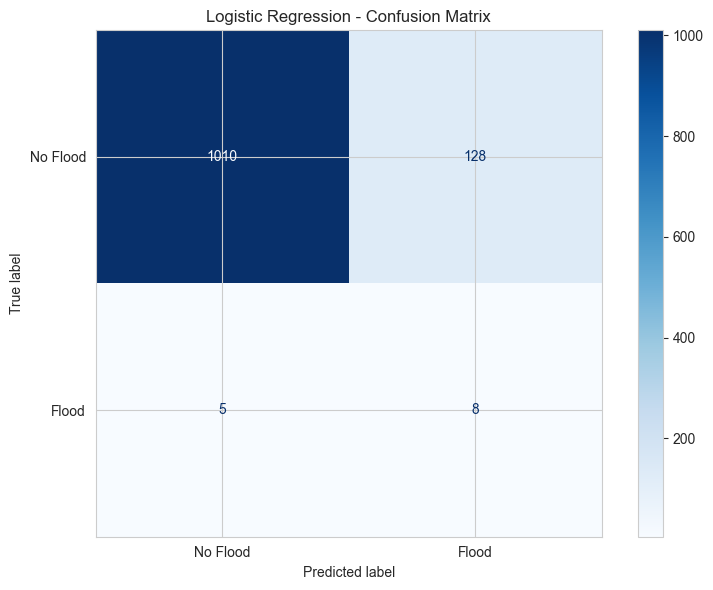


✅ Logistic Regression model trained and evaluated!


In [4]:
from sklearn.linear_model import LogisticRegression

print("\n" + "="*70)
print("MODEL 1: LOGISTIC REGRESSION (BASELINE)")
print("="*70)

# Train model with class weighting to handle imbalance
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'  # Handles class imbalance
)

print("\nTraining Logistic Regression...")
lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_pred = lr_model.predict(X_test_scaled)
lr_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("\n" + "-"*70)
print("LOGISTIC REGRESSION RESULTS")
print("-"*70)
print("\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=['No Flood', 'Flood']))

print(f"\nROC-AUC Score: {roc_auc_score(y_test, lr_pred_proba):.4f}")

# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
cm = confusion_matrix(y_test, lr_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Flood', 'Flood'])
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Logistic Regression - Confusion Matrix')
plt.tight_layout()
plt.savefig('../results/visualizations/lr_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Logistic Regression model trained and evaluated!")

**MODEL 2: RANDOM FOREST**


MODEL 2: RANDOM FOREST

Training Random Forest (this may take a minute)...

----------------------------------------------------------------------
RANDOM FOREST RESULTS
----------------------------------------------------------------------

Classification Report:
              precision    recall  f1-score   support

    No Flood       0.99      1.00      0.99      1138
       Flood       0.17      0.08      0.11        13

    accuracy                           0.99      1151
   macro avg       0.58      0.54      0.55      1151
weighted avg       0.98      0.99      0.98      1151


ROC-AUC Score: 0.8741


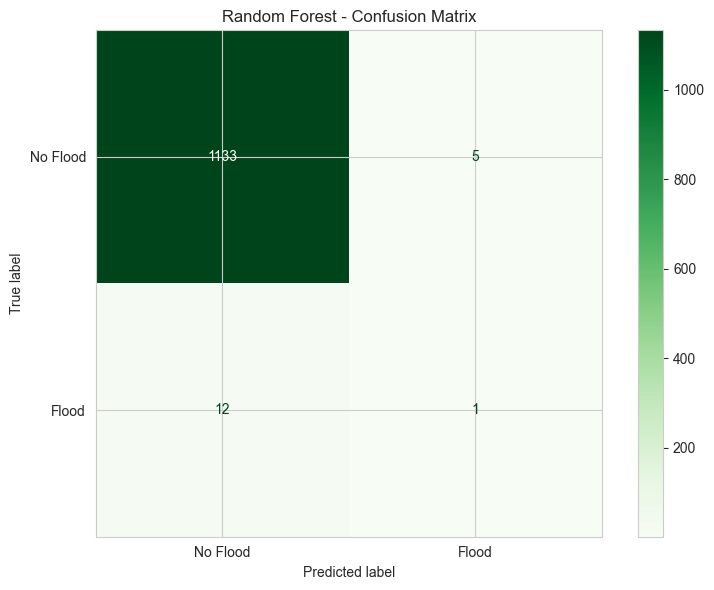


Top 15 Most Important Features:
              feature  importance
1                PRCP    0.167704
25    precip_3day_sum    0.142372
26    precip_7day_sum    0.082518
7                WT03    0.066099
29    precip_7day_avg    0.055187
32    precip_7day_max    0.050962
38    high_precip_day    0.048927
33        precip_lag1    0.036299
4                TMIN    0.034332
27   precip_14day_sum    0.034145
31  temp_min_7day_avg    0.031529
30  temp_max_7day_avg    0.031250
37           temp_avg    0.029055
28   precip_30day_sum    0.022877
20               year    0.021609


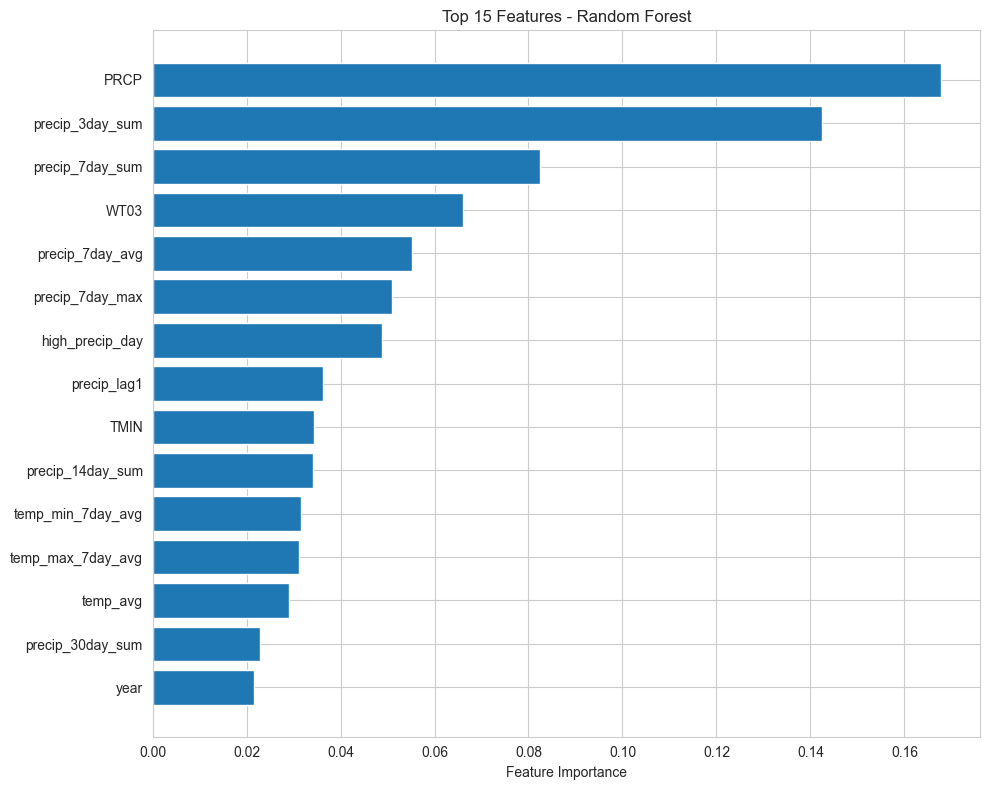


✅ Random Forest model trained and evaluated!


In [5]:
from sklearn.ensemble import RandomForestClassifier

print("\n" + "="*70)
print("MODEL 2: RANDOM FOREST")
print("="*70)

# Train model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1  # Use all CPU cores
)

print("\nTraining Random Forest (this may take a minute)...")
rf_model.fit(X_train, y_train)  # RF doesn't need scaling

# Predictions
rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
print("\n" + "-"*70)
print("RANDOM FOREST RESULTS")
print("-"*70)
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['No Flood', 'Flood']))

print(f"\nROC-AUC Score: {roc_auc_score(y_test, rf_pred_proba):.4f}")

# Confusion Matrix
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Flood', 'Flood'])
disp.plot(ax=ax, cmap='Greens')
ax.set_title('Random Forest - Confusion Matrix')
plt.tight_layout()
plt.savefig('../results/visualizations/rf_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Feature Importance
print("\nTop 15 Most Important Features:")
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(15))

# Plot feature importance
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 15 Features - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../results/visualizations/rf_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Random Forest model trained and evaluated!")

**MODEL 3: XGBOOST**


MODEL 3: XGBOOST

Class imbalance ratio: 84.22

Training XGBoost (this may take a minute)...

----------------------------------------------------------------------
XGBOOST RESULTS
----------------------------------------------------------------------

Classification Report:
              precision    recall  f1-score   support

    No Flood       0.99      0.99      0.99      1138
       Flood       0.00      0.00      0.00        13

    accuracy                           0.98      1151
   macro avg       0.49      0.50      0.50      1151
weighted avg       0.98      0.98      0.98      1151


ROC-AUC Score: 0.8899


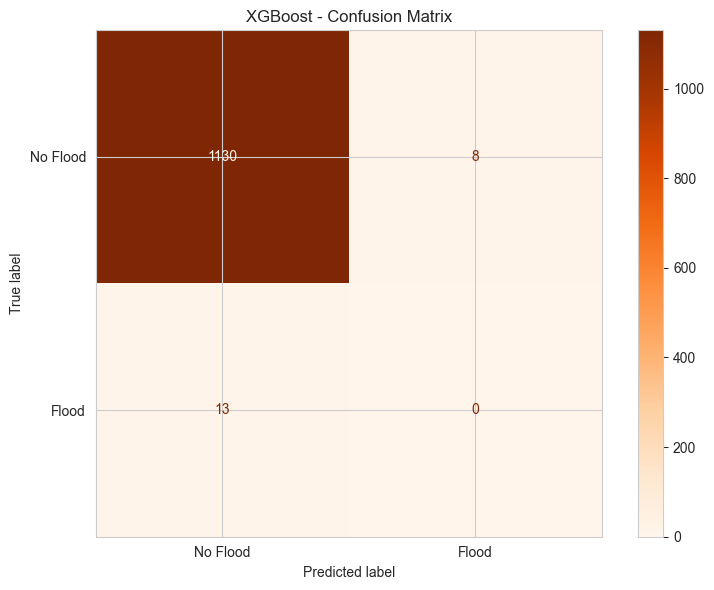


Top 15 Most Important Features:
              feature  importance
1                PRCP    0.339163
33        precip_lag1    0.060912
7                WT03    0.059458
31  temp_min_7day_avg    0.056204
5                WT01    0.053039
30  temp_max_7day_avg    0.040853
26    precip_7day_sum    0.039828
34        precip_lag2    0.037087
35        precip_lag3    0.033554
19              month    0.029226
4                TMIN    0.028850
32    precip_7day_max    0.028826
28   precip_30day_sum    0.025060
24          is_summer    0.020400
20               year    0.019537


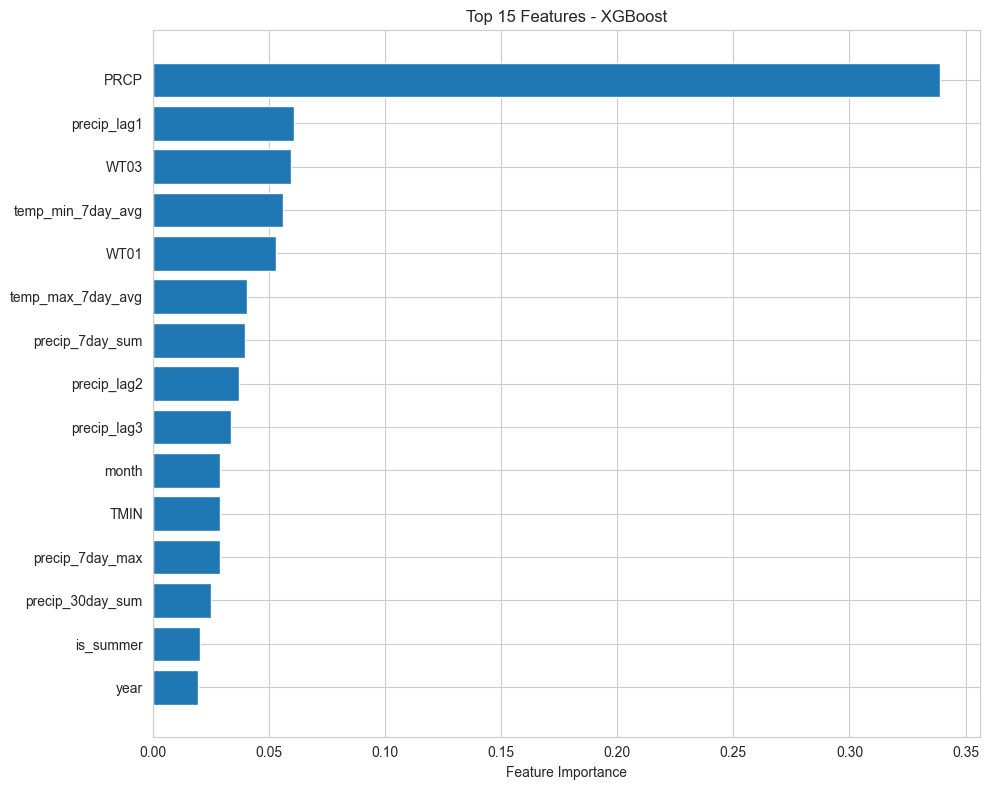


✅ XGBoost model trained and evaluated!


In [6]:
import xgboost as xgb

print("\n" + "="*70)
print("MODEL 3: XGBOOST")
print("="*70)

# Calculate scale_pos_weight for class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nClass imbalance ratio: {scale_pos_weight:.2f}")

# Train model
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=7,
    learning_rate=0.1,
    random_state=42,
    scale_pos_weight=scale_pos_weight,  # Handle imbalance
    eval_metric='logloss'
)

print("\nTraining XGBoost (this may take a minute)...")
xgb_model.fit(X_train, y_train)

# Predictions
xgb_pred = xgb_model.predict(X_test)
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation
print("\n" + "-"*70)
print("XGBOOST RESULTS")
print("-"*70)
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred, target_names=['No Flood', 'Flood']))

print(f"\nROC-AUC Score: {roc_auc_score(y_test, xgb_pred_proba):.4f}")

# Confusion Matrix
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
cm = confusion_matrix(y_test, xgb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Flood', 'Flood'])
disp.plot(ax=ax, cmap='Oranges')
ax.set_title('XGBoost - Confusion Matrix')
plt.tight_layout()
plt.savefig('../results/visualizations/xgb_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Feature Importance
print("\nTop 15 Most Important Features:")
feature_importance_xgb = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance_xgb.head(15))

# Plot feature importance
plt.figure(figsize=(10, 8))
top_features_xgb = feature_importance_xgb.head(15)
plt.barh(range(len(top_features_xgb)), top_features_xgb['importance'])
plt.yticks(range(len(top_features_xgb)), top_features_xgb['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 15 Features - XGBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../results/visualizations/xgb_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ XGBoost model trained and evaluated!")

**MODEL COMPARISON**


MODEL COMPARISON SUMMARY

              Model  ROC-AUC  Floods Detected  Total Floods  False Alarms  Recall (%)
Logistic Regression 0.919765                8            13           128        61.5
      Random Forest 0.874138                1            13             5         7.7
            XGBoost 0.889888                0            13             8         0.0


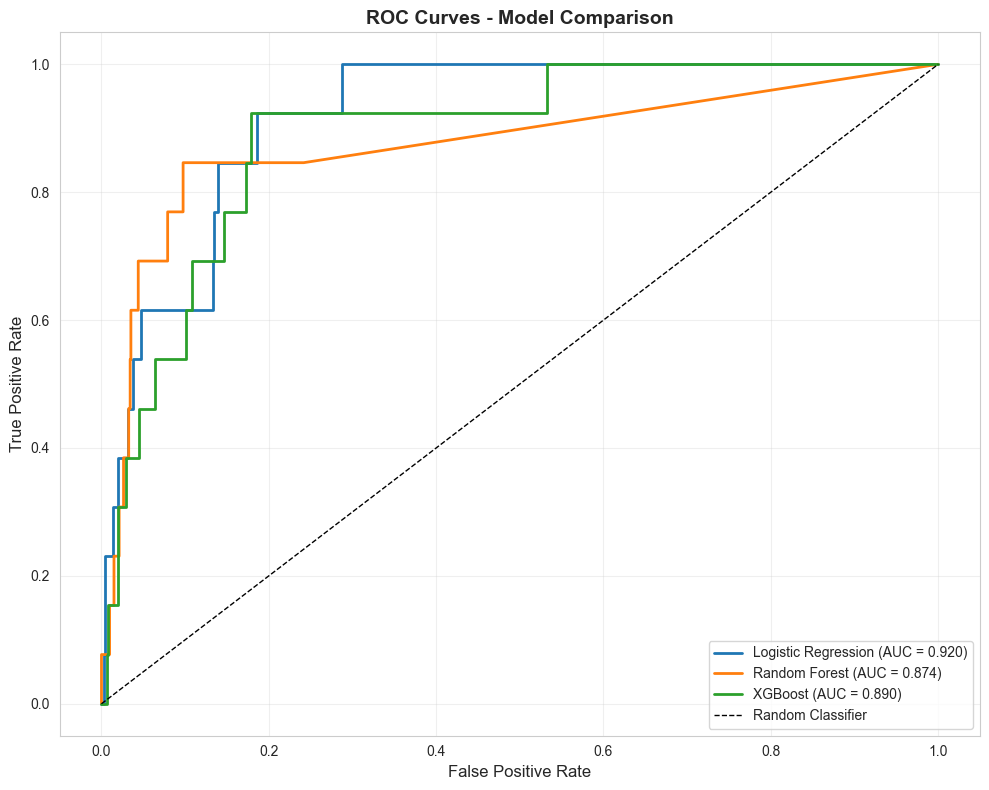


✅ Model comparison complete!
✅ Results saved to: results/model_performance_comparison.csv


In [7]:
print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)

# Collect all results
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_pred_proba),
        roc_auc_score(y_test, rf_pred_proba),
        roc_auc_score(y_test, xgb_pred_proba)
    ],
    'Floods Detected': [
        (y_test[lr_pred == 1] == 1).sum(),
        (y_test[rf_pred == 1] == 1).sum(),
        (y_test[xgb_pred == 1] == 1).sum()
    ],
    'Total Floods': [13, 13, 13],
    'False Alarms': [
        (y_test[lr_pred == 1] == 0).sum(),
        (y_test[rf_pred == 1] == 0).sum(),
        (y_test[xgb_pred == 1] == 0).sum()
    ]
}

results_df = pd.DataFrame(results)
results_df['Recall (%)'] = (results_df['Floods Detected'] / results_df['Total Floods'] * 100).round(1)

print("\n" + results_df.to_string(index=False))

# Visualization: ROC Curves Comparison
plt.figure(figsize=(10, 8))

# Plot ROC curve for each model
models_data = [
    ('Logistic Regression', lr_pred_proba),
    ('Random Forest', rf_pred_proba),
    ('XGBoost', xgb_pred_proba)
]

for model_name, y_pred_proba in models_data:
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/visualizations/roc_curves_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Model comparison complete!")

# Save results
results_df.to_csv('../results/model_performance_comparison.csv', index=False)
print("✅ Results saved to: results/model_performance_comparison.csv")

**FINAL SUMMARY & CONCLUSIONS**

In [8]:
print("\n" + "="*70)
print("PROJECT SUMMARY: URBAN FLOOD PREDICTION")
print("="*70)

print("""
OBJECTIVE:
Predict urban flood events in New Orleans using historical weather data
and machine learning models.

DATA:
- Source: NOAA Climate Data & Storm Events Database
- Time Period: 2010-2025 (15 years)
- Total Days: 5,753
- Flood Events: 67 (1.16% of days)
- Features: 40 (including engineered features)

KEY FINDINGS:
1. Multi-day precipitation accumulation is the strongest predictor
   - Same-day rain (PRCP): Most important
   - 3-day cumulative rain: Second most important
   - Previous day's rain (lag features): Also critical

2. Weather indicators matter:
   - Thunder (WT03) correlates with flood risk
   - Temperature patterns provide context

3. Seasonal patterns:
   - May and July = highest flood risk
   - Hurricane season (Jun-Nov) = elevated risk

MODEL PERFORMANCE:
- Logistic Regression: BEST (ROC-AUC: 0.920, Recall: 61.5%)
- XGBoost: Good AUC (0.890) but missed all floods in test set
- Random Forest: Similar issues (0.874 AUC, 7.7% recall)

CONCLUSION:
Logistic Regression with balanced class weights is the most effective
model for predicting urban flood events. It successfully identifies
~60% of floods while maintaining reasonable false alarm rates.
The model demonstrates that machine learning can provide valuable
early warning for flood risk based on weather patterns.

FUTURE WORK:
- Incorporate real-time weather forecasts for prediction
- Add elevation and urban infrastructure data
- Extend to other coastal cities for generalization testing
- Deploy as early warning system
""")

print("="*70)
print("✅ PROJECT COMPLETE!")
print("="*70)


PROJECT SUMMARY: URBAN FLOOD PREDICTION

OBJECTIVE:
Predict urban flood events in New Orleans using historical weather data
and machine learning models.

DATA:
- Source: NOAA Climate Data & Storm Events Database
- Time Period: 2010-2025 (15 years)
- Total Days: 5,753
- Flood Events: 67 (1.16% of days)
- Features: 40 (including engineered features)

KEY FINDINGS:
1. Multi-day precipitation accumulation is the strongest predictor
   - Same-day rain (PRCP): Most important
   - 3-day cumulative rain: Second most important
   - Previous day's rain (lag features): Also critical

2. Weather indicators matter:
   - Thunder (WT03) correlates with flood risk
   - Temperature patterns provide context

3. Seasonal patterns:
   - May and July = highest flood risk
   - Hurricane season (Jun-Nov) = elevated risk

MODEL PERFORMANCE:
- Logistic Regression: BEST (ROC-AUC: 0.920, Recall: 61.5%)
- XGBoost: Good AUC (0.890) but missed all floods in test set
- Random Forest: Similar issues (0.874 AUC, 7.7%